In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

seed= 42

In [65]:
def preprocess_data(data):
    df= data.copy()

    df.drop(columns=['SampleID'])

    return df

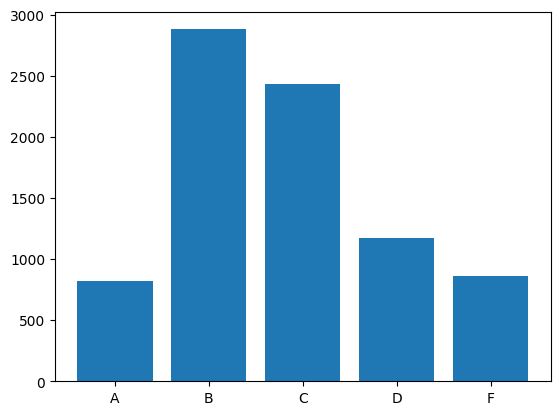

In [66]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

le= LabelEncoder()

train_df= pd.read_csv("train.csv")
test_df= pd.read_csv("test.csv")

X= preprocess_data(train_df.drop(columns=['Relative Performance Rating']))
y= le.fit_transform(train_df['Relative Performance Rating'])

X_train, X_eval, y_train, y_eval = train_test_split(X, y, train_size=0.8, stratify= y, random_state=seed)

X_test= preprocess_data(test_df)

plt.bar(le.inverse_transform(np.unique_counts(y).values), np.unique_counts(y).counts)
plt.show()

In [72]:
# Subtask 1

answer1= pd.DataFrame([{
    'subtaskID': 1,
    'datapointID': 1,
    'answer': len(test_df[
        (test_df['County'] == 'ANDERSON') &
        (test_df['School Type'] == 'Elementary')
        ])
}])

answer1.head()

,subtaskID,datapointID,answer
0,1,1,1


In [68]:
# Subtask 2

answer2= pd.DataFrame([{
    'subtaskID': 2,
    'datapointID': 2,
    'answer': test_df['Academic Growth Rating'].value_counts().index[0]
}])

answer2.head()

,subtaskID,datapointID,answer
0,2,2,C


In [69]:
# Subtask 3
from catboost import CatBoostClassifier

cat_cols= X.select_dtypes(include= ['object', 'str']).columns.to_list()

model= CatBoostClassifier(
    iterations= 3000,
    learning_rate= 0.03,
    depth=6,
    cat_features= cat_cols,
    auto_class_weights= "Balanced",
    early_stopping_rounds= 200,
    random_state= seed
)

model.fit(
    X_train,y_train,
    eval_set= [(X_eval, y_eval)],
    verbose=200
)

0:	learn: 1.5415157	test: 1.5391652	best: 1.5391652 (0)	total: 42.6ms	remaining: 2m 7s
200:	learn: 0.3413364	test: 0.3528040	best: 0.3528040 (200)	total: 5.39s	remaining: 1m 15s
400:	learn: 0.2761365	test: 0.3109834	best: 0.3109834 (400)	total: 11s	remaining: 1m 11s
600:	learn: 0.2383142	test: 0.2952622	best: 0.2952622 (600)	total: 17.1s	remaining: 1m 8s
800:	learn: 0.2115639	test: 0.2882526	best: 0.2882526 (800)	total: 22.8s	remaining: 1m 2s
1000:	learn: 0.1923064	test: 0.2843269	best: 0.2843209 (998)	total: 28.4s	remaining: 56.8s
1200:	learn: 0.1755045	test: 0.2818797	best: 0.2818618 (1198)	total: 34.1s	remaining: 51s
1400:	learn: 0.1608092	test: 0.2810390	best: 0.2809901 (1396)	total: 39.8s	remaining: 45.4s
1600:	learn: 0.1495036	test: 0.2806238	best: 0.2804709 (1568)	total: 45.3s	remaining: 39.6s
1800:	learn: 0.1388233	test: 0.2805865	best: 0.2803384 (1687)	total: 51s	remaining: 33.9s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.2803383911
bestIteration = 16

CatBoostClassifier(auto_class_weights='Balanced', cat_features=['County', 'School Type', 'Alternative Education Accountability', 'Charter', 'Overall Rating', 'Student Achievement Rating', 'School Progress Rating', 'Academic Growth Rating', 'Closing the Gaps Rating'], depth=6, early_stopping_rounds=200, iterations=3000, learning_rate=0.03, random_state=42)

In [70]:
predictions= le.inverse_transform(model.predict(X_test).ravel())

answer3= pd.DataFrame([{
    'subtaskID': 3,
    'datapointID': id_,
    'answer': pred
} for id_, pred in zip(test_df['SampleID'], predictions)])

answer3.head()

,subtaskID,datapointID,answer
0,3,8168,B
1,3,8169,C
2,3,8170,F
3,3,8171,C
4,3,8172,C


In [73]:
answer= pd.concat([answer1, answer2, answer3])
answer.to_csv("submission.csv", index=  False)